# Initial Exploratory Analaysis

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import json
import pandas as pd
from esda.moran import Moran
from esda.geary import Geary
from libpysal.weights import Queen
import geopandas as gpd
from shapely.geometry import shape
from spreg import ML_Lag, OLS
from sklearn.model_selection import train_test_split





KeyboardInterrupt: 

#### Preliminary Data Overview

In [ ]:
# Load dataset and imd to create merged dataset with target variable

dataset = pd.read_parquet('combined_indicators.parquet', engine='fastparquet')

imd_rank = pd.read_csv('imd_2025_rank.csv')
imd_score = pd.read_csv('imd_2025_scores.csv')

imd_rank.rename(columns={'LSOA code (2021)': 'lsoa_code',
                         'Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)': 'imd_rank'
                        }, inplace=True)
imd_score.rename(columns={'LSOA code (2021)': 'lsoa_code',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

dataset = dataset.merge(imd_rank[['lsoa_code', 'imd_rank']], on='lsoa_code', how='left')
dataset = dataset.merge(imd_score[['lsoa_code', 'imd_score']], on='lsoa_code', how='left')
features = dataset.select_dtypes(include=['float64', 'int64','uint32'])
target_rank = dataset['imd_rank']
target_score = dataset['imd_score'] 

In [101]:
dataset_debug = pd.read_parquet('combined_indicators_new.parquet', engine='fastparquet')
dataset_debug = dataset_debug.merge(imd_rank[['lsoa_code', 'imd_rank']], on='lsoa_code', how='left')
dataset_debug = dataset_debug.merge(imd_score[['lsoa_code', 'imd_score']], on='lsoa_code', how='left')

In [84]:
# Initial info on dataset

print('dataset dimensions:', dataset.shape, end='\n\n')
print('dataset feature datatype counts:', end='\n')
print(dataset.dtypes.value_counts())

dataset dimensions: (268, 427)

dataset feature datatype counts:
float64    319
int64       72
uint32      35
object       1
Name: count, dtype: int64


In [85]:
# Observe missingness

missingness = dataset.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(dataset)) * 100
missingness_df = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})
print(missingness_df.head(10))


                                             feature  missing_count  \
0  ratio_alcohol_gambling_to_cultural_entertainme...            199   
1  ratio_alcohol_gambling_to_cultural_entertainme...            175   
2    ratio_healthcare_access_to_alcohol_gambling_500            147   
3  ratio_public_amenities_environment_to_alcohol_...            147   
4  ratio_childcare_early_years_to_alcohol_gamblin...            147   
5   ratio_financial_services_to_alcohol_gambling_500            147   
6     ratio_education_skills_to_alcohol_gambling_500            147   
7   ratio_essential_services_to_alcohol_gambling_500            147   
8  ratio_professional_services_to_community_socia...            135   
9  ratio_alcohol_gambling_to_cultural_entertainme...            120   

   missing_percent  
0        74.253731  
1        65.298507  
2        54.850746  
3        54.850746  
4        54.850746  
5        54.850746  
6        54.850746  
7        54.850746  
8        50.373134  
9       

In [86]:
'''After observing some features have high missingness,
until the issue is resolved, features above 20% are dropped and the rest are filled with median values'''

dataset = dataset.drop(columns=missingness_df[missingness_df['missing_percent'] > 20]['feature'])
dataset = dataset.fillna(dataset.median(numeric_only=True)) 


In [87]:
low_var = features.var().sort_values()
print(low_var.head(20))

count_elderly_care_2000              0.000000e+00
count_elderly_care_1500              0.000000e+00
count_elderly_care_5000              0.000000e+00
count_elderly_care_2500              0.000000e+00
count_elderly_care_1000              0.000000e+00
count_elderly_care_750               0.000000e+00
count_elderly_care_500               0.000000e+00
count_elderly_care_250               0.000000e+00
count_elderly_care_1250              0.000000e+00
count_elderly_care_0                 0.000000e+00
landuse_greenhouse_horticulture_0    2.616736e-09
landuse_conservation_0               5.260551e-09
landuse_storage_0                    1.786530e-08
landuse_flowerbed_0                  1.169328e-07
landuse_landfill_0                   2.035365e-07
landuse_garages_0                    3.368681e-07
landuse_education_0                  5.222352e-07
landuse_orchard_0                    6.137848e-07
landuse_terminal_0                   2.329483e-06
landuse_religious_0                  9.525352e-06


In [88]:
target = dataset['imd_rank']
features = dataset.drop(columns=['lsoa_code', 'imd_rank'])

In [105]:


for col in dataset_debug:
    if col in dataset.columns:
        #if not dataset_debug[col].equals(dataset[col]):
        #    print(f"Column '{col}' differs between datasets.")
        pass

    else:
        print(col)

nearest_shop
ratio_fastfood_to_dining_1000


In [99]:
print(dataset_debug['count_alcohol_gambling_0'].sum())
print(dataset_debug['count_alcohol_gambling_250'].sum())
print(dataset_debug['count_alcohol_gambling_500'].sum())
print(dataset_debug['count_alcohol_gambling_2000'].sum())

print()

print(dataset['count_alcohol_gambling_0'].sum())
print(dataset['count_alcohol_gambling_250'].sum())
print(dataset['count_alcohol_gambling_500'].sum())
print(dataset['count_alcohol_gambling_2000'].sum())



#for item in dataset.columns:
#    print(item)

59.0
257.0
540.0
3980.0

59.0
257.0
540.0
3980.0


#### Correlation Analysis

In [80]:
# Correlation of features with IMD ranking
target_corr = dataset.corr(numeric_only=True)["imd_rank"].sort_values(ascending=False)

target_corr.head(20)

imd_rank                                   1.000000
F_mean_price                               0.488630
T_mean_price                               0.481346
S_mean_price                               0.477806
%_claims_sfw                               0.471374
count_childcare_early_years_2500           0.462136
D_mean_price                               0.430506
count_public_services_civic_500            0.421124
count_public_services_civic_750            0.410889
count_public_services_civic_1000           0.400964
count_childcare_early_years_2000           0.396043
count_public_services_civic_250            0.392591
count_public_services_civic_1250           0.388875
count_public_services_civic_1500           0.387602
count_public_services_civic_2000           0.376479
count_waste_sanitation_5000                0.359533
count_public_services_civic_2500           0.354578
D_count_transactions                       0.345633
count_retail_commerce_5000                 0.343869
count_public

#### PCA

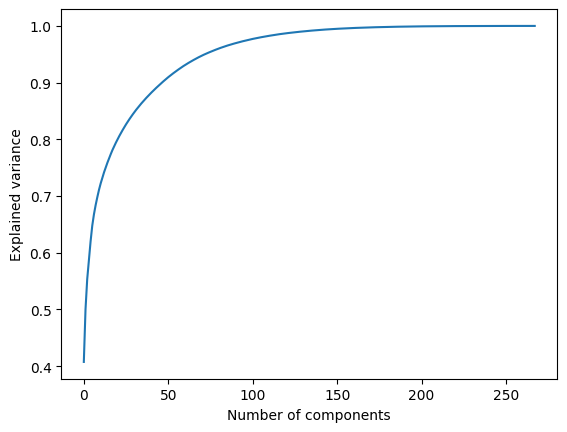

In [17]:
# Perform PCA

X = dataset.drop(columns=["imd_rank", "lsoa_code"])

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum())
plt.ylabel("Explained variance")
plt.xlabel("Number of components")
plt.show()

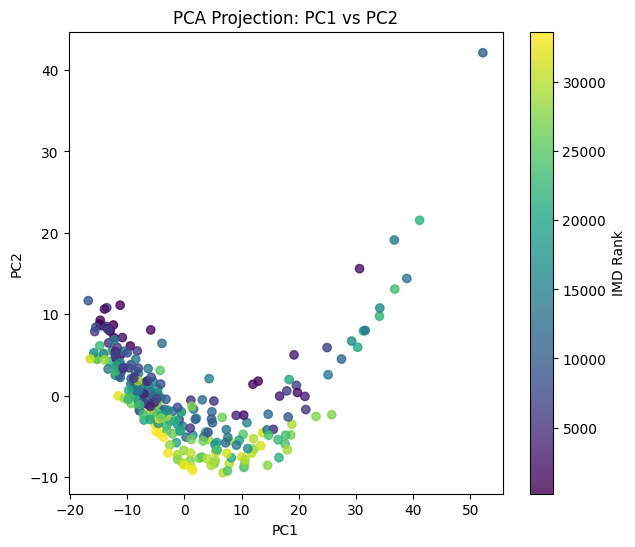

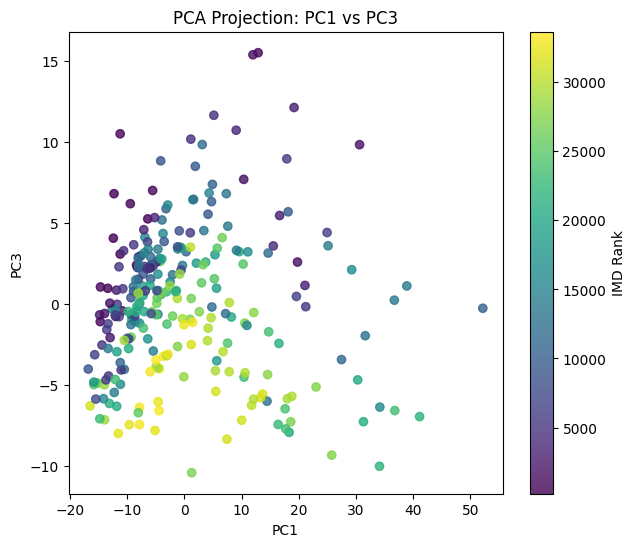

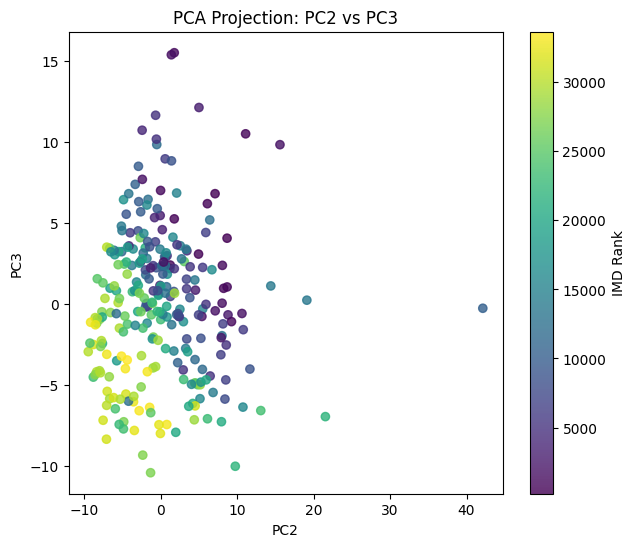

In [18]:
# Get scatterplot of described principal component pairs 

pairs = [(0,1), (0,2), (1,2)]

for i, j in pairs:
    plt.figure(figsize=(7,6))
    plt.scatter(
        X_pca[:, i],
        X_pca[:, j],
        c=dataset["imd_rank"],
        cmap="viridis",
        alpha=0.8
    )
    
    plt.xlabel(f"PC{i+1}")
    plt.ylabel(f"PC{j+1}")
    plt.title(f"PCA Projection: PC{i+1} vs PC{j+1}")
    plt.colorbar(label="IMD Rank")
    plt.show()

In [19]:
# Get contributions of original features to principal components

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns
)

# Observe within the first principal component, which features have the highest absolute contributions

loadings["PC1"].abs().sort_values(ascending=False).head(10)

count_waste_sanitation_1500                0.077157
count_waste_sanitation_1250                0.077082
count_sustainable_transport_1250           0.076882
count_waste_sanitation_1000                0.076729
count_sustainable_transport_1500           0.076660
count_sustainable_transport_1000           0.076367
count_retail_commerce_1500                 0.076350
count_public_amenities_environment_1500    0.076252
count_retail_commerce_1250                 0.076220
count_public_amenities_environment_1250    0.076092
Name: PC1, dtype: float64

In [20]:
# Determine number of components to retain for 95% variance

np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1

np.int64(73)

#### Spatial Analysis and Modelling

In [ ]:
# Preparoatory for spatial modelling

lsoa_shapes =  pd.read_csv('geography_lookup.csv')

# Convert GeoJSON string to Shapely geometry
lsoa_shapes['geometry'] = lsoa_shapes['geo_shape'].apply(lambda x: shape(json.loads(x)))
lsoa_shapes = lsoa_shapes[['lsoa_code', 'geometry']]
gdf = gpd.GeoDataFrame(lsoa_shapes, geometry='geometry')
gdf.crs = "EPSG:4326"  # sets the cooordinat ereference system to lat/long

# Join for full geospatial dataset
gdf_full = gdf.merge(dataset, on="lsoa_code", how="left")


# Build adjacency matrix
w = Queen.from_dataframe(gdf_full)
w.transform = "r"  # row-standardized
adj_matrix, ids = w.full() # check what ids are in the adjacency matrix


# Setup data for modelling
y_spatial = dataset["imd_score"].values.reshape(-1,1)
X_spatial = X_pca[:, :73] X  # use PCA components

C:\Users\danie\AppData\Local\Temp\ipykernel_8364\198934109.py:16: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_full)


In [75]:
'''Get Moran's I  and Geary’s C for the target variable.
These check for spatial autocorrelation. Moran's I evaluates autocorrelation
on a global scale whereas Geary’s C is more sensiitive to local autocorrelation'''

moran = Moran(gdf_full['imd_rank'].values, w)
geary = Geary(gdf_full["imd_rank"].values, w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim, end='\n\n')

print("Geary's C:", geary.C)
print("p-value:", geary.p_sim)

Moran's I: 0.5771405555723713
p-value: 0.001

Geary's C: 0.4105571049439279
p-value: 0.001


In [76]:
# OLS

ols_model = OLS(
    y_spatial,
    X_spatial,
    name_y="imd_rank"
)

print(ols_model.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
-----------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :    imd_rank                Number of Observations:         268
Mean dependent var  :     22.2555                Number of Variables   :          74
S.D. dependent var  :     15.9439                Degrees of Freedom    :         194
R-squared           :      0.9538
Adjusted R-squared  :      0.9364
Sum squared residual:     3134.51                F-statistic           :     54.8875
Sigma-square        :      16.157                Prob(F-statistic)     :   1.171e-98
S.E. of regression  :       4.020                Log likelihood        :    -709.814
Sigma-square ML     :      11.696                Akaike info criterion :    1567.628
S.E of regression ML:      3.4199                Schwarz criterion     :    1833.361

------------------------------------------------------------

In [77]:
# SAR

sar_model = ML_Lag(
    y_spatial,
    X_spatial,
    w=w,
    name_y="imd_rank"
)

print("SAR Model's Summary: \n", sar_model.summary)
print('SAR Model rho value:',sar_model.rho)
sar_m = Moran(sar_model.u, w)
print("SAR Model Moran's I:", sar_m.I)
print("SAR Model's Respective Moran's I p-value:", sar_m.p_sim)

SAR Model's Summary: 
 REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :    imd_rank                Number of Observations:         268
Mean dependent var  :     22.2555                Number of Variables   :          75
S.D. dependent var  :     15.9439                Degrees of Freedom    :         193
Pseudo R-squared    :      0.9539
Spatial Pseudo R-squared:  0.9539
Log likelihood      :   -709.5110
Sigma-square ML     :     11.6680                Akaike info criterion :    1569.022
S.E of regression   :      3.4158                Schwarz criterion     :    1838.346

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
----------------------------------------

In [79]:
# SDM

sdm_model = ML_Lag(
    y_spatial,
    X_spatial,
    w=w,
    slx_lags=1,
    name_y="imd_rank"
)
print("SDM Model's Summary: \n", sdm_model.summary)
print('SDM Model rho value:', sdm_model.rho)    
sdm_m = Moran(sdm_model.u, w)
print("SDM Model Moran's I:", sdm_m.I)
print("SDM Model's Respective Moran's I p-value:", sdm_m.p_sim)

SDM Model's Summary: 
 REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
-------------------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :    imd_rank                Number of Observations:         268
Mean dependent var  :     22.2555                Number of Variables   :         148
S.D. dependent var  :     15.9439                Degrees of Freedom    :         120
Pseudo R-squared    :      0.9718
Spatial Pseudo R-squared:  0.9710
Log likelihood      :   -644.3873
Sigma-square ML     :      7.1388                Akaike info criterion :    1584.775
S.E of regression   :      2.6719                Schwarz criterion     :    2116.241

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-St